<a href="https://colab.research.google.com/github/anaseddaif03-png/Agentic-ML-problem-solver-with-LangGraph/blob/main/AGENTIC_ML_PROBLEM_SOLVER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install langgraph langchain langchain-community langchain-mistralai
!pip install scikit-learn pandas numpy matplotlib seaborn
!pip install python-dotenv

In [1]:
!pip install langgraph langchain langchain-community langchain-mistralai
!pip install scikit-learn pandas numpy matplotlib seaborn
!pip install python-dotenv


In [13]:
!pip install langgraph langchain langchain-mistralai scikit-learn pandas numpy matplotlib


🤖 AGENTIC ML WORKFLOW – CLI MODE
   Powered by Mistral 7B + LangGraph

🔑 Enter Mistral API Key: HDjc178QItk5AV8NxoLnHcr1wRvWxNpb 
📂 Enter path to CSV dataset: /content/iris-dataset.csv

📝 Describe your ML problem:
> i have iris data and want to classify species: setosa, versicolor, virginica

🚀 STARTING WORKFLOW...

📂 Loading dataset...
✅ Loaded 150 rows, 6 columns
🤖 Analyzing problem with Mistral 7B...
✅ Detected problem type: CLASSIFICATION
💡 Reasoning: The task involves predicting predefined categories (setosa, versicolor, virginica) from the given features, which is a supervised learning problem.
🎯 Target column identified: Species
🔧 Preprocessing data...
✅ Preprocessed shape: (150, 5)
⚙️ Optimizing hyperparameters...
✅ Using K (neighbors): 3
🚀 Executing algorithm...
✅ KNN completed - Accuracy: 1.0000

🎉 WORKFLOW COMPLETED SUCCESSFULLY

📊 Problem Type: CLASSIFICATION
------------------------------------------------------------
✅ K (neighbors): 3
🎯 Accuracy: 1.0000

📦 Predicted Clas

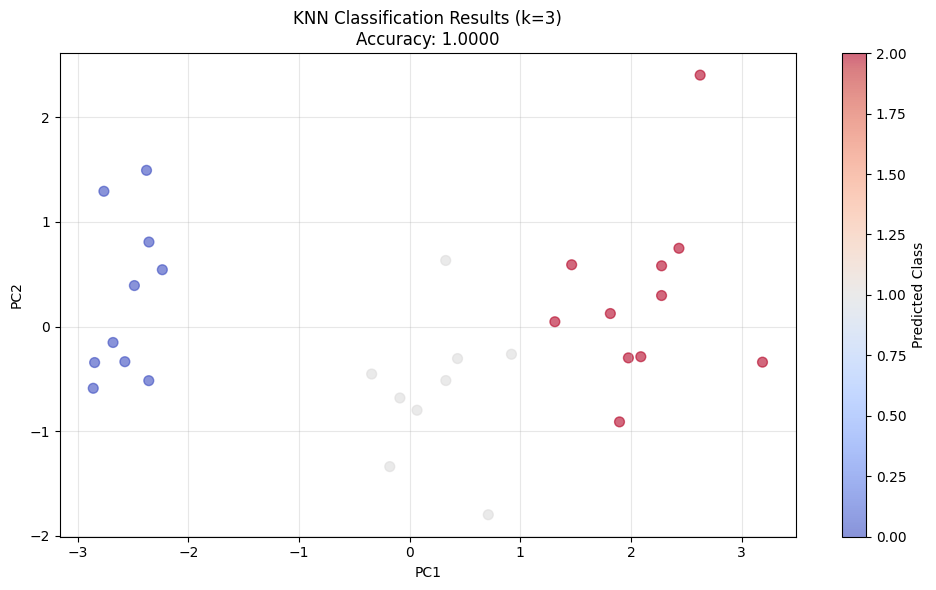

In [14]:
"""
Agentic ML Workflow with LangGraph, Mistral 7B, and Tkinter
CLI + GUI compatible - Google Colab Ready

Installation Instructions for Google Colab:
!pip install langgraph langchain langchain-community langchain-mistralai
!pip install scikit-learn pandas numpy matplotlib seaborn
"""

import os
import json
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, silhouette_score
import matplotlib.pyplot as plt

from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_mistralai import ChatMistralAI


# =========================
# HELPER FUNCTIONS
# =========================

def safe_json_parse(text: str):
    """Parse JSON from LLM response, handling markdown fences"""
    try:
        # Remove markdown fences if present
        if "```json" in text:
            text = text.split("```json")[1].split("```")[0].strip()
        elif "```" in text:
            text = text.split("```")[1].split("```")[0].strip()

        # Extract JSON object
        start = text.find("{")
        end = text.rfind("}") + 1

        if start == -1 or end == 0:
            raise ValueError("No JSON object found")

        return json.loads(text[start:end])

    except Exception as e:
        raise ValueError(f"LLM JSON parsing failed. Raw output:\n{text}") from e


# =========================
# STATE DEFINITION
# =========================

class MLState(TypedDict):
    description: str
    dataset_path: str
    dataset: pd.DataFrame
    problem_type: str
    preprocessed_data: np.ndarray
    target: np.ndarray
    optimal_k: int
    results: dict
    error: str


# =========================
# AGENTIC WORKFLOW
# =========================

class MLAgenticWorkflow:
    def __init__(self, mistral_api_key: str):
        self.llm = ChatMistralAI(
            model="mistral-small-latest",
            api_key=mistral_api_key,
            temperature=0
        )
        self.workflow = self._build_workflow()

    def _build_workflow(self):
        """Build LangGraph workflow"""
        workflow = StateGraph(MLState)

        workflow.add_node("load_data", self.load_data_node)
        workflow.add_node("analyze_problem", self.analyze_problem_node)
        workflow.add_node("preprocess_data", self.preprocess_data_node)
        workflow.add_node("optimize_hyperparameters", self.optimize_hyperparameters_node)
        workflow.add_node("execute_algorithm", self.execute_algorithm_node)

        workflow.set_entry_point("load_data")
        workflow.add_edge("load_data", "analyze_problem")
        workflow.add_edge("analyze_problem", "preprocess_data")
        workflow.add_edge("preprocess_data", "optimize_hyperparameters")
        workflow.add_edge("optimize_hyperparameters", "execute_algorithm")
        workflow.add_edge("execute_algorithm", END)

        return workflow.compile()

    def load_data_node(self, state: MLState) -> MLState:
        """Node 1: Load CSV dataset"""
        try:
            print("📂 Loading dataset...")
            state["dataset"] = pd.read_csv(state["dataset_path"])
            state["error"] = ""
            print(f"✅ Loaded {len(state['dataset'])} rows, {len(state['dataset'].columns)} columns")
        except Exception as e:
            state["error"] = f"Data loading failed: {e}"
            print(f"❌ {state['error']}")
        return state

    def analyze_problem_node(self, state: MLState) -> MLState:
        """Node 2: Use Mistral LLM to analyze problem type"""
        if state.get("error"):
            return state

        try:
            print("🤖 Analyzing problem with Mistral 7B...")
            df = state["dataset"]

            prompt = f"""
You are an ML expert.

Determine if this is a classification or clustering problem.

User description:
{state["description"]}

Dataset columns:
{df.columns.tolist()}

Sample data:
{df.head(3).to_string()}

Respond ONLY in JSON format:
{{
  "problem_type": "classification" or "clustering",
  "target_column": "column_name" or null,
  "reasoning": "brief explanation"
}}
"""
            response = self.llm.invoke(prompt)
            content = response.content.strip()

            result = safe_json_parse(content)

            state["problem_type"] = result["problem_type"].lower()
            print(f"✅ Detected problem type: {state['problem_type'].upper()}")
            print(f"💡 Reasoning: {result.get('reasoning', 'N/A')}")

            if state["problem_type"] == "classification" and result.get("target_column"):
                target_col = result["target_column"]
                if target_col in df.columns:
                    state["target"] = df[target_col].values
                    state["dataset"] = df.drop(columns=[target_col])
                    print(f"🎯 Target column identified: {target_col}")
                else:
                    print(f"⚠️ Target column '{target_col}' not found, using last column")
                    state["target"] = df.iloc[:, -1].values
                    state["dataset"] = df.iloc[:, :-1]

        except Exception as e:
            state["error"] = f"Problem analysis failed: {e}"
            print(f"❌ {state['error']}")

        return state

    def preprocess_data_node(self, state: MLState) -> MLState:
        """Node 3: Handle missing values and scaling"""
        if state.get("error"):
            return state

        try:
            print("🔧 Preprocessing data...")
            df = state["dataset"].select_dtypes(include=[np.number])

            # Handle missing values
            df = df.fillna(df.mean())

            # Scale features
            scaler = StandardScaler()
            state["preprocessed_data"] = scaler.fit_transform(df)

            # Encode target for classification
            if state["problem_type"] == "classification" and state.get("target") is not None:
                le = LabelEncoder()
                state["target"] = le.fit_transform(state["target"])

            print(f"✅ Preprocessed shape: {state['preprocessed_data'].shape}")

        except Exception as e:
            state["error"] = f"Preprocessing failed: {e}"
            print(f"❌ {state['error']}")

        return state

    def optimize_hyperparameters_node(self, state: MLState) -> MLState:
        """Node 4: Optimize k using elbow method for clustering"""
        if state.get("error"):
            return state

        try:
            print("⚙️ Optimizing hyperparameters...")

            if state["problem_type"] == "clustering":
                X = state["preprocessed_data"]
                scores = []
                k_range = range(2, min(11, len(X)))

                for k in k_range:
                    km = KMeans(n_clusters=k, n_init=10, random_state=42)
                    labels = km.fit_predict(X)
                    scores.append(silhouette_score(X, labels))

                state["optimal_k"] = k_range[np.argmax(scores)]
                print(f"✅ Optimal K (clusters): {state['optimal_k']}")
            else:
                state["optimal_k"] = 3  # Default for KNN
                print(f"✅ Using K (neighbors): {state['optimal_k']}")

        except Exception as e:
            state["error"] = f"Hyperparameter optimization failed: {e}"
            print(f"❌ {state['error']}")

        return state

    def execute_algorithm_node(self, state: MLState) -> MLState:
        """Node 5: Execute KMeans or KNN"""
        if state.get("error"):
            return state

        try:
            print("🚀 Executing algorithm...")
            X = state["preprocessed_data"]
            k = state["optimal_k"]

            if state["problem_type"] == "clustering":
                # KMeans clustering
                km = KMeans(n_clusters=k, n_init=10, random_state=42)
                labels = km.fit_predict(X)

                state["results"] = {
                    "optimal_k": k,
                    "silhouette_score": silhouette_score(X, labels),
                    "labels": labels,
                    "X": X
                }
                print(f"✅ KMeans completed - Silhouette Score: {state['results']['silhouette_score']:.4f}")

            else:
                # KNN classification
                Xtr, Xte, ytr, yte = train_test_split(
                    X, state["target"], test_size=0.2, random_state=42
                )
                knn = KNeighborsClassifier(n_neighbors=k)
                knn.fit(Xtr, ytr)
                preds = knn.predict(Xte)

                state["results"] = {
                    "k": k,
                    "accuracy": accuracy_score(yte, preds),
                    "predictions": preds,
                    "actual": yte,
                    "X_test": Xte
                }
                print(f"✅ KNN completed - Accuracy: {state['results']['accuracy']:.4f}")

        except Exception as e:
            state["error"] = f"Algorithm execution failed: {e}"
            print(f"❌ {state['error']}")

        return state

    def run(self, description: str, dataset_path: str) -> MLState:
        """Run the complete workflow"""
        return self.workflow.invoke({
            "description": description,
            "dataset_path": dataset_path,
            "dataset": None,
            "problem_type": "",
            "preprocessed_data": None,
            "target": None,
            "optimal_k": 0,
            "results": {},
            "error": ""
        })


# =========================
# VISUALIZATION
# =========================

def visualize_results(state: MLState):
    """Create visualizations for results"""
    if state.get("error"):
        return

    results = state["results"]
    problem_type = state["problem_type"]

    if problem_type == "clustering":
        # Clustering visualization
        X = results["X"]
        labels = results["labels"]
        k = results["optimal_k"]

        # Use PCA for 2D if needed
        if X.shape[1] > 2:
            pca = PCA(n_components=2)
            X_2d = pca.fit_transform(X)
            xlabel, ylabel = "PC1", "PC2"
        else:
            X_2d = X[:, :2]
            xlabel, ylabel = "Feature 1", "Feature 2"

        plt.figure(figsize=(10, 6))
        scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis', alpha=0.6, s=50)
        plt.colorbar(scatter, label='Cluster')
        plt.title(f'KMeans Clustering Results (k={k})\nSilhouette Score: {results["silhouette_score"]:.4f}')
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    else:
        # Classification visualization
        X = results["X_test"]
        preds = results["predictions"]
        k = results["k"]

        # Use PCA for 2D if needed
        if X.shape[1] > 2:
            pca = PCA(n_components=2)
            X_2d = pca.fit_transform(X)
            xlabel, ylabel = "PC1", "PC2"
        else:
            X_2d = X[:, :2]
            xlabel, ylabel = "Feature 1", "Feature 2"

        plt.figure(figsize=(10, 6))
        scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=preds, cmap='coolwarm', alpha=0.6, s=50)
        plt.colorbar(scatter, label='Predicted Class')
        plt.title(f'KNN Classification Results (k={k})\nAccuracy: {results["accuracy"]:.4f}')
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


def print_results(state: MLState):
    """Print detailed results"""
    if state.get("error"):
        print("\n" + "="*60)
        print("❌ WORKFLOW FAILED")
        print("="*60)
        print(f"Error: {state['error']}")
        return

    print("\n" + "="*60)
    print("🎉 WORKFLOW COMPLETED SUCCESSFULLY")
    print("="*60)

    print(f"\n📊 Problem Type: {state['problem_type'].upper()}")
    print("-"*60)

    results = state["results"]

    if state["problem_type"] == "clustering":
        print(f"✅ Optimal K (clusters): {results['optimal_k']}")
        print(f"📈 Silhouette Score: {results['silhouette_score']:.4f}")

        unique, counts = np.unique(results['labels'], return_counts=True)
        print(f"\n📦 Cluster Distribution:")
        for cluster, count in zip(unique, counts):
            print(f"   Cluster {cluster}: {count} samples ({count/len(results['labels'])*100:.1f}%)")

    else:
        print(f"✅ K (neighbors): {results['k']}")
        print(f"🎯 Accuracy: {results['accuracy']:.4f}")

        unique, counts = np.unique(results['predictions'], return_counts=True)
        print(f"\n📦 Predicted Class Distribution:")
        for cls, count in zip(unique, counts):
            print(f"   Class {cls}: {count} samples ({count/len(results['predictions'])*100:.1f}%)")

        most_common = unique[np.argmax(counts)]
        print(f"\n🏆 Most Common Predicted Class: {most_common}")

    print("\n" + "="*60)


# =========================
# CLI RUNNER
# =========================

def run_ml_pipeline_cli():
    """Run the ML pipeline in CLI mode"""
    print("="*60)
    print("🤖 AGENTIC ML WORKFLOW – CLI MODE")
    print("   Powered by Mistral 7B + LangGraph")
    print("="*60)

    # Get API Key
    api_key = input("\n🔑 Enter Mistral API Key: ").strip()
    if not api_key:
        print("❌ API key is required")
        return

    # Get Dataset Path
    dataset_path = input("📂 Enter path to CSV dataset: ").strip()
    if not os.path.exists(dataset_path):
        print(f"❌ Dataset file not found: {dataset_path}")
        return

    # Get Description
    print("\n📝 Describe your ML problem:")
    description = input("> ").strip()
    if not description:
        print("❌ Description is required")
        return

    print("\n" + "="*60)
    print("🚀 STARTING WORKFLOW...")
    print("="*60 + "\n")

    # Run workflow
    try:
        workflow = MLAgenticWorkflow(api_key)
        state = workflow.run(description, dataset_path)

        # Print results
        print_results(state)

        # Visualize
        if not state.get("error"):
            print("\n📊 Generating visualization...")
            visualize_results(state)

    except Exception as e:
        print(f"\n❌ FATAL ERROR: {e}")
        import traceback
        traceback.print_exc()


# =========================
# ENTRY POINT
# =========================

if __name__ == "__main__":
    run_ml_pipeline_cli()

🤖 AGENTIC ML WORKFLOW – CLI MODE
   Powered by Mistral 7B + LangGraph

✅ API Key loaded from myenv file
📂 Enter path to CSV dataset: /content/iris-dataset.csv

📝 Describe your ML problem:
> i have iris data and want to classify species: setosa, versicolor, virginica

🚀 STARTING WORKFLOW...

📂 Loading dataset...
✅ Loaded 150 rows, 6 columns
🤖 Analyzing problem with Mistral 7B...
✅ Detected problem type: CLASSIFICATION
💡 Reasoning: The task involves predicting predefined categories (setosa, versicolor, virginica) from the given features, which is a supervised learning problem.
🎯 Target column identified: Species
🔧 Preprocessing data...
✅ Preprocessed shape: (150, 5)
⚙️ Optimizing hyperparameters...
✅ Using K (neighbors): 3
🚀 Executing algorithm...
✅ KNN completed - Accuracy: 1.0000

🎉 WORKFLOW COMPLETED SUCCESSFULLY

📊 Problem Type: CLASSIFICATION
------------------------------------------------------------
✅ K (neighbors): 3
🎯 Accuracy: 1.0000

📦 Predicted Class Distribution:
   Class 0

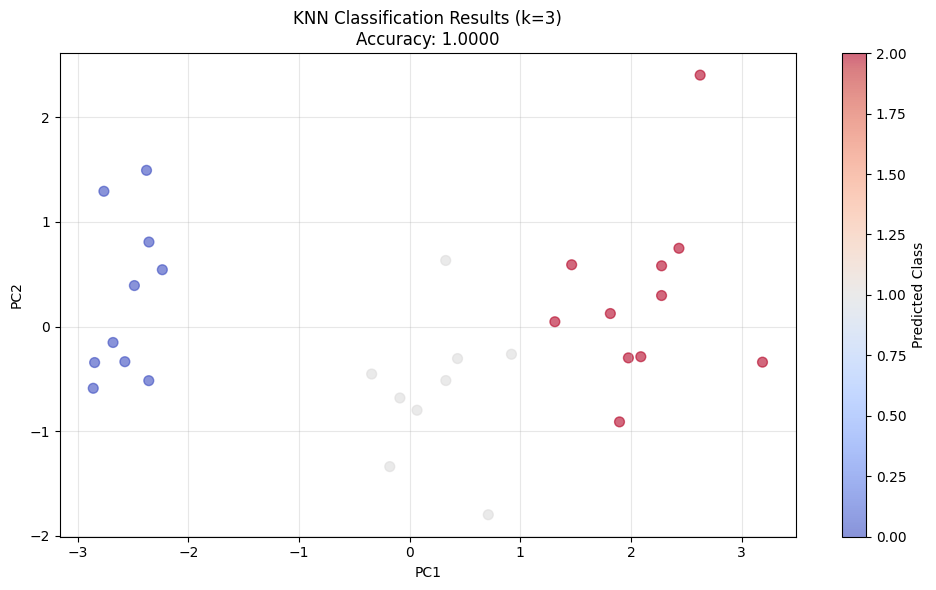

In [20]:
"""
Agentic ML Workflow with LangGraph, Mistral 7B, and Tkinter
CLI + GUI compatible - Google Colab Ready

Installation Instructions for Google Colab:
!pip install langgraph langchain langchain-community langchain-mistralai
!pip install scikit-learn pandas numpy matplotlib seaborn
!pip install python-dotenv
"""

import os
import json
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, silhouette_score
import matplotlib.pyplot as plt
from dotenv import load_dotenv

from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_mistralai import ChatMistralAI


# =========================
# HELPER FUNCTIONS
# =========================

def safe_json_parse(text: str):
    """Parse JSON from LLM response, handling markdown fences"""
    try:
        # Remove markdown fences if present
        if "```json" in text:
            text = text.split("```json")[1].split("```")[0].strip()
        elif "```" in text:
            text = text.split("```")[1].split("```")[0].strip()

        # Extract JSON object
        start = text.find("{")
        end = text.rfind("}") + 1

        if start == -1 or end == 0:
            raise ValueError("No JSON object found")

        return json.loads(text[start:end])

    except Exception as e:
        raise ValueError(f"LLM JSON parsing failed. Raw output:\n{text}") from e


# =========================
# STATE DEFINITION
# =========================

class MLState(TypedDict):
    description: str
    dataset_path: str
    dataset: pd.DataFrame
    problem_type: str
    preprocessed_data: np.ndarray
    target: np.ndarray
    optimal_k: int
    results: dict
    error: str


# =========================
# AGENTIC WORKFLOW
# =========================

class MLAgenticWorkflow:
    def __init__(self, mistral_api_key: str):
        self.llm = ChatMistralAI(
            model="mistral-small-latest",
            api_key=mistral_api_key,
            temperature=0
        )
        self.workflow = self._build_workflow()

    def _build_workflow(self):
        """Build LangGraph workflow"""
        workflow = StateGraph(MLState)

        workflow.add_node("load_data", self.load_data_node)
        workflow.add_node("analyze_problem", self.analyze_problem_node)
        workflow.add_node("preprocess_data", self.preprocess_data_node)
        workflow.add_node("optimize_hyperparameters", self.optimize_hyperparameters_node)
        workflow.add_node("execute_algorithm", self.execute_algorithm_node)

        workflow.set_entry_point("load_data")
        workflow.add_edge("load_data", "analyze_problem")
        workflow.add_edge("analyze_problem", "preprocess_data")
        workflow.add_edge("preprocess_data", "optimize_hyperparameters")
        workflow.add_edge("optimize_hyperparameters", "execute_algorithm")
        workflow.add_edge("execute_algorithm", END)

        return workflow.compile()

    def load_data_node(self, state: MLState) -> MLState:
        """Node 1: Load CSV dataset"""
        try:
            print("📂 Loading dataset...")
            state["dataset"] = pd.read_csv(state["dataset_path"])
            state["error"] = ""
            print(f"✅ Loaded {len(state['dataset'])} rows, {len(state['dataset'].columns)} columns")
        except Exception as e:
            state["error"] = f"Data loading failed: {e}"
            print(f"❌ {state['error']}")
        return state

    def analyze_problem_node(self, state: MLState) -> MLState:
        """Node 2: Use Mistral LLM to analyze problem type"""
        if state.get("error"):
            return state

        try:
            print("🤖 Analyzing problem with Mistral 7B...")
            df = state["dataset"]

            prompt = f"""
You are an ML expert.

Determine if this is a classification or clustering problem.

User description:
{state["description"]}

Dataset columns:
{df.columns.tolist()}

Sample data:
{df.head(3).to_string()}

Respond ONLY in JSON format:
{{
  "problem_type": "classification" or "clustering",
  "target_column": "column_name" or null,
  "reasoning": "brief explanation"
}}
"""
            response = self.llm.invoke(prompt)
            content = response.content.strip()

            result = safe_json_parse(content)

            state["problem_type"] = result["problem_type"].lower()
            print(f"✅ Detected problem type: {state['problem_type'].upper()}")
            print(f"💡 Reasoning: {result.get('reasoning', 'N/A')}")

            if state["problem_type"] == "classification" and result.get("target_column"):
                target_col = result["target_column"]
                if target_col in df.columns:
                    state["target"] = df[target_col].values
                    state["dataset"] = df.drop(columns=[target_col])
                    print(f"🎯 Target column identified: {target_col}")
                else:
                    print(f"⚠️ Target column '{target_col}' not found, using last column")
                    state["target"] = df.iloc[:, -1].values
                    state["dataset"] = df.iloc[:, :-1]

        except Exception as e:
            state["error"] = f"Problem analysis failed: {e}"
            print(f"❌ {state['error']}")

        return state

    def preprocess_data_node(self, state: MLState) -> MLState:
        """Node 3: Handle missing values and scaling"""
        if state.get("error"):
            return state

        try:
            print("🔧 Preprocessing data...")
            df = state["dataset"].select_dtypes(include=[np.number])

            # Handle missing values
            df = df.fillna(df.mean())

            # Scale features
            scaler = StandardScaler()
            state["preprocessed_data"] = scaler.fit_transform(df)

            # Encode target for classification
            if state["problem_type"] == "classification" and state.get("target") is not None:
                le = LabelEncoder()
                state["target"] = le.fit_transform(state["target"])

            print(f"✅ Preprocessed shape: {state['preprocessed_data'].shape}")

        except Exception as e:
            state["error"] = f"Preprocessing failed: {e}"
            print(f"❌ {state['error']}")

        return state

    def optimize_hyperparameters_node(self, state: MLState) -> MLState:
        """Node 4: Optimize k using elbow method for clustering"""
        if state.get("error"):
            return state

        try:
            print("⚙️ Optimizing hyperparameters...")

            if state["problem_type"] == "clustering":
                X = state["preprocessed_data"]
                scores = []
                k_range = range(2, min(11, len(X)))

                for k in k_range:
                    km = KMeans(n_clusters=k, n_init=10, random_state=42)
                    labels = km.fit_predict(X)
                    scores.append(silhouette_score(X, labels))

                state["optimal_k"] = k_range[np.argmax(scores)]
                print(f"✅ Optimal K (clusters): {state['optimal_k']}")
            else:
                state["optimal_k"] = 3  # Default for KNN
                print(f"✅ Using K (neighbors): {state['optimal_k']}")

        except Exception as e:
            state["error"] = f"Hyperparameter optimization failed: {e}"
            print(f"❌ {state['error']}")

        return state

    def execute_algorithm_node(self, state: MLState) -> MLState:
        """Node 5: Execute KMeans or KNN"""
        if state.get("error"):
            return state

        try:
            print("🚀 Executing algorithm...")
            X = state["preprocessed_data"]
            k = state["optimal_k"]

            if state["problem_type"] == "clustering":
                # KMeans clustering
                km = KMeans(n_clusters=k, n_init=10, random_state=42)
                labels = km.fit_predict(X)

                state["results"] = {
                    "optimal_k": k,
                    "silhouette_score": silhouette_score(X, labels),
                    "labels": labels,
                    "X": X
                }
                print(f"✅ KMeans completed - Silhouette Score: {state['results']['silhouette_score']:.4f}")

            else:
                # KNN classification
                Xtr, Xte, ytr, yte = train_test_split(
                    X, state["target"], test_size=0.2, random_state=42
                )
                knn = KNeighborsClassifier(n_neighbors=k)
                knn.fit(Xtr, ytr)
                preds = knn.predict(Xte)

                state["results"] = {
                    "k": k,
                    "accuracy": accuracy_score(yte, preds),
                    "predictions": preds,
                    "actual": yte,
                    "X_test": Xte
                }
                print(f"✅ KNN completed - Accuracy: {state['results']['accuracy']:.4f}")

        except Exception as e:
            state["error"] = f"Algorithm execution failed: {e}"
            print(f"❌ {state['error']}")

        return state

    def run(self, description: str, dataset_path: str) -> MLState:
        """Run the complete workflow"""
        return self.workflow.invoke({
            "description": description,
            "dataset_path": dataset_path,
            "dataset": None,
            "problem_type": "",
            "preprocessed_data": None,
            "target": None,
            "optimal_k": 0,
            "results": {},
            "error": ""
        })


# =========================
# VISUALIZATION
# =========================

def visualize_results(state: MLState):
    """Create visualizations for results"""
    if state.get("error"):
        return

    results = state["results"]
    problem_type = state["problem_type"]

    if problem_type == "clustering":
        # Clustering visualization
        X = results["X"]
        labels = results["labels"]
        k = results["optimal_k"]

        # Use PCA for 2D if needed
        if X.shape[1] > 2:
            pca = PCA(n_components=2)
            X_2d = pca.fit_transform(X)
            xlabel, ylabel = "PC1", "PC2"
        else:
            X_2d = X[:, :2]
            xlabel, ylabel = "Feature 1", "Feature 2"

        plt.figure(figsize=(10, 6))
        scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis', alpha=0.6, s=50)
        plt.colorbar(scatter, label='Cluster')
        plt.title(f'KMeans Clustering Results (k={k})\nSilhouette Score: {results["silhouette_score"]:.4f}')
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    else:
        # Classification visualization
        X = results["X_test"]
        preds = results["predictions"]
        k = results["k"]

        # Use PCA for 2D if needed
        if X.shape[1] > 2:
            pca = PCA(n_components=2)
            X_2d = pca.fit_transform(X)
            xlabel, ylabel = "PC1", "PC2"
        else:
            X_2d = X[:, :2]
            xlabel, ylabel = "Feature 1", "Feature 2"

        plt.figure(figsize=(10, 6))
        scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=preds, cmap='coolwarm', alpha=0.6, s=50)
        plt.colorbar(scatter, label='Predicted Class')
        plt.title(f'KNN Classification Results (k={k})\nAccuracy: {results["accuracy"]:.4f}')
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


def print_results(state: MLState):
    """Print detailed results"""
    if state.get("error"):
        print("\n" + "="*60)
        print("❌ WORKFLOW FAILED")
        print("="*60)
        print(f"Error: {state['error']}")
        return

    print("\n" + "="*60)
    print("🎉 WORKFLOW COMPLETED SUCCESSFULLY")
    print("="*60)

    print(f"\n📊 Problem Type: {state['problem_type'].upper()}")
    print("-"*60)

    results = state["results"]

    if state["problem_type"] == "clustering":
        print(f"✅ Optimal K (clusters): {results['optimal_k']}")
        print(f"📈 Silhouette Score: {results['silhouette_score']:.4f}")

        unique, counts = np.unique(results['labels'], return_counts=True)
        print(f"\n📦 Cluster Distribution:")
        for cluster, count in zip(unique, counts):
            print(f"   Cluster {cluster}: {count} samples ({count/len(results['labels'])*100:.1f}%)")

    else:
        print(f"✅ K (neighbors): {results['k']}")
        print(f"🎯 Accuracy: {results['accuracy']:.4f}")

        unique, counts = np.unique(results['predictions'], return_counts=True)
        print(f"\n📦 Predicted Class Distribution:")
        for cls, count in zip(unique, counts):
            print(f"   Class {cls}: {count} samples ({count/len(results['predictions'])*100:.1f}%)")

        most_common = unique[np.argmax(counts)]
        print(f"\n🏆 Most Common Predicted Class: {most_common}")

    print("\n" + "="*60)


# =========================
# CLI RUNNER
# =========================

def run_ml_pipeline_cli():
    """Run the ML pipeline in CLI mode"""
    print("="*60)
    print("🤖 AGENTIC ML WORKFLOW – CLI MODE")
    print("   Powered by Mistral 7B + LangGraph")
    print("="*60)

    # Load environment variables from .env file
    load_dotenv('myenv')

    # Try to get API key from environment variable
    api_key = os.getenv('MISTRAL_API_KEY')

    if api_key:
        print("\n✅ API Key loaded from myenv file")
    else:
        # Fallback to manual input if not found in .env
        print("\n⚠️ MISTRAL_API_KEY not found in myenv file")
        api_key = input("🔑 Enter Mistral API Key manually: ").strip()
        if not api_key:
            print("❌ API key is required")
            return

    # Get Dataset Path
    dataset_path = input("📂 Enter path to CSV dataset: ").strip()
    if not os.path.exists(dataset_path):
        print(f"❌ Dataset file not found: {dataset_path}")
        return

    # Get Description
    print("\n📝 Describe your ML problem:")
    description = input("> ").strip()
    if not description:
        print("❌ Description is required")
        return

    print("\n" + "="*60)
    print("🚀 STARTING WORKFLOW...")
    print("="*60 + "\n")

    # Run workflow
    try:
        workflow = MLAgenticWorkflow(api_key)
        state = workflow.run(description, dataset_path)

        # Print results
        print_results(state)

        # Visualize
        if not state.get("error"):
            print("\n📊 Generating visualization...")
            visualize_results(state)

    except Exception as e:
        print(f"\n❌ FATAL ERROR: {e}")
        import traceback
        traceback.print_exc()


# =========================
# ENTRY POINT
# =========================

if __name__ == "__main__":
    run_ml_pipeline_cli()

🤖 AGENTIC ML WORKFLOW – ENHANCED VISUAL DASHBOARD
   Powered by Mistral 7B + LangGraph + Rich Visualizations

✅ API Key loaded from myenv file
📂 Enter path to CSV dataset: /content/customer_segmentation.csv

📝 Describe your ML problem:
> ihave this data and i don't know what to do segmentation or classification 

🚀 STARTING AGENTIC WORKFLOW...

📂 Loading dataset...
✅ Loaded 2240 rows, 29 columns
🤖 Analyzing problem with Mistral 7B...
✅ Detected problem type: CLASSIFICATION
💡 LLM Reasoning: This is a classification problem because the dataset contains a target column named 'Response' which...
🎯 Target column identified: Response
🔧 Preprocessing data...
✅ Preprocessed shape: (2240, 25)
⚙️ Optimizing hyperparameters...
✅ Using K (neighbors): 3
🚀 Executing algorithm...
✅ KNN completed - Accuracy: 0.8415

🎉 WORKFLOW COMPLETED SUCCESSFULLY!

📋 DETAILED RESULTS TABLE

📊 DATASET INFORMATION
--------------------------------------------------------------------------------
          Metric       

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.draw()
/usr/

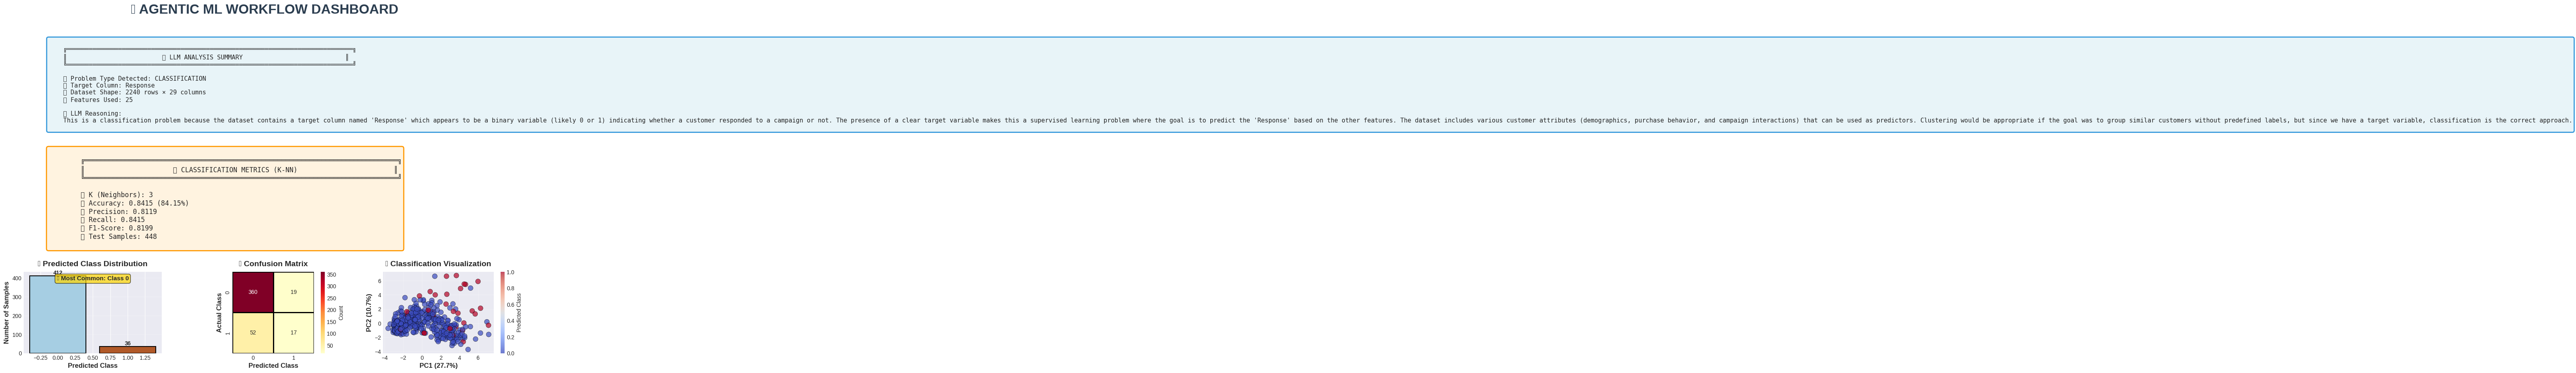

In [5]:
"""
Agentic ML Workflow with LangGraph, Mistral 7B
Enhanced Visual Dashboard - Google Colab Ready

Installation Instructions for Google Colab:
!pip install langgraph langchain langchain-community langchain-mistralai
!pip install scikit-learn pandas numpy matplotlib seaborn
!pip install python-dotenv
"""

import os
import json
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, silhouette_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_mistralai import ChatMistralAI

# Set style for beautiful plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


# =========================
# HELPER FUNCTIONS
# =========================

def safe_json_parse(text: str):
    """Parse JSON from LLM response, handling markdown fences"""
    try:
        # Remove markdown fences if present
        if "```json" in text:
            text = text.split("```json")[1].split("```")[0].strip()
        elif "```" in text:
            text = text.split("```")[1].split("```")[0].strip()

        # Extract JSON object
        start = text.find("{")
        end = text.rfind("}") + 1

        if start == -1 or end == 0:
            raise ValueError("No JSON object found")

        return json.loads(text[start:end])

    except Exception as e:
        raise ValueError(f"LLM JSON parsing failed. Raw output:\n{text}") from e


# =========================
# STATE DEFINITION
# =========================

class MLState(TypedDict):
    description: str
    dataset_path: str
    dataset: pd.DataFrame
    original_dataset: pd.DataFrame
    problem_type: str
    llm_reasoning: str
    target_column: str
    preprocessed_data: np.ndarray
    target: np.ndarray
    optimal_k: int
    k_scores: list
    results: dict
    error: str


# =========================
# AGENTIC WORKFLOW
# =========================

class MLAgenticWorkflow:
    def __init__(self, mistral_api_key: str):
        self.llm = ChatMistralAI(
            model="mistral-small-latest",
            api_key=mistral_api_key,
            temperature=0
        )
        self.workflow = self._build_workflow()

    def _build_workflow(self):
        """Build LangGraph workflow"""
        workflow = StateGraph(MLState)

        workflow.add_node("load_data", self.load_data_node)
        workflow.add_node("analyze_problem", self.analyze_problem_node)
        workflow.add_node("preprocess_data", self.preprocess_data_node)
        workflow.add_node("optimize_hyperparameters", self.optimize_hyperparameters_node)
        workflow.add_node("execute_algorithm", self.execute_algorithm_node)

        workflow.set_entry_point("load_data")
        workflow.add_edge("load_data", "analyze_problem")
        workflow.add_edge("analyze_problem", "preprocess_data")
        workflow.add_edge("preprocess_data", "optimize_hyperparameters")
        workflow.add_edge("optimize_hyperparameters", "execute_algorithm")
        workflow.add_edge("execute_algorithm", END)

        return workflow.compile()

    def load_data_node(self, state: MLState) -> MLState:
        """Node 1: Load CSV dataset"""
        try:
            print("📂 Loading dataset...")
            df = pd.read_csv(state["dataset_path"])
            state["dataset"] = df.copy()
            state["original_dataset"] = df.copy()
            state["error"] = ""
            print(f"✅ Loaded {len(df)} rows, {len(df.columns)} columns")
        except Exception as e:
            state["error"] = f"Data loading failed: {e}"
            print(f"❌ {state['error']}")
        return state

    def analyze_problem_node(self, state: MLState) -> MLState:
        """Node 2: Use Mistral LLM to analyze problem type"""
        if state.get("error"):
            return state

        try:
            print("🤖 Analyzing problem with Mistral 7B...")
            df = state["dataset"]

            prompt = f"""
You are an ML expert.

Determine if this is a classification or clustering problem.

User description:
{state["description"]}

Dataset columns:
{df.columns.tolist()}

Sample data:
{df.head(3).to_string()}

Dataset info:
- Rows: {len(df)}
- Columns: {len(df.columns)}
- Numeric columns: {len(df.select_dtypes(include=[np.number]).columns)}

Respond ONLY in JSON format:
{{
  "problem_type": "classification" or "clustering",
  "target_column": "column_name" or null,
  "reasoning": "detailed explanation of why this is classification/clustering and what patterns you observed"
}}
"""

            response = self.llm.invoke(prompt)
            content = response.content.strip()

            result = safe_json_parse(content)

            state["problem_type"] = result["problem_type"].lower()
            state["llm_reasoning"] = result.get("reasoning", "No reasoning provided")
            state["target_column"] = result.get("target_column", "")

            print(f"✅ Detected problem type: {state['problem_type'].upper()}")
            print(f"💡 LLM Reasoning: {state['llm_reasoning'][:100]}...")

            if state["problem_type"] == "classification" and result.get("target_column"):
                target_col = result["target_column"]
                if target_col in df.columns:
                    state["target"] = df[target_col].values
                    state["dataset"] = df.drop(columns=[target_col])
                    print(f"🎯 Target column identified: {target_col}")
                else:
                    print(f"⚠️ Target column '{target_col}' not found, using last column")
                    state["target"] = df.iloc[:, -1].values
                    state["dataset"] = df.iloc[:, :-1]
                    state["target_column"] = df.columns[-1]

        except Exception as e:
            state["error"] = f"Problem analysis failed: {e}"
            print(f"❌ {state['error']}")

        return state

    def preprocess_data_node(self, state: MLState) -> MLState:
        """Node 3: Handle missing values and scaling"""
        if state.get("error"):
            return state

        try:
            print("🔧 Preprocessing data...")
            df = state["dataset"].select_dtypes(include=[np.number])

            # Handle missing values
            df = df.fillna(df.mean())

            # Scale features
            scaler = StandardScaler()
            state["preprocessed_data"] = scaler.fit_transform(df)

            # Encode target for classification
            if state["problem_type"] == "classification" and state.get("target") is not None:
                le = LabelEncoder()
                state["target"] = le.fit_transform(state["target"])

            print(f"✅ Preprocessed shape: {state['preprocessed_data'].shape}")

        except Exception as e:
            state["error"] = f"Preprocessing failed: {e}"
            print(f"❌ {state['error']}")

        return state

    def optimize_hyperparameters_node(self, state: MLState) -> MLState:
        """Node 4: Optimize k using elbow method for clustering"""
        if state.get("error"):
            return state

        try:
            print("⚙️ Optimizing hyperparameters...")

            if state["problem_type"] == "clustering":
                X = state["preprocessed_data"]
                scores = []
                inertias = []
                k_range = range(2, min(11, len(X)))

                for k in k_range:
                    km = KMeans(n_clusters=k, n_init=10, random_state=42)
                    labels = km.fit_predict(X)
                    scores.append(silhouette_score(X, labels))
                    inertias.append(km.inertia_)

                optimal_idx = np.argmax(scores)
                state["optimal_k"] = k_range[optimal_idx]
                state["k_scores"] = list(zip(k_range, scores, inertias))
                print(f"✅ Optimal K (clusters): {state['optimal_k']}")
            else:
                state["optimal_k"] = 3  # Default for KNN
                state["k_scores"] = []
                print(f"✅ Using K (neighbors): {state['optimal_k']}")

        except Exception as e:
            state["error"] = f"Hyperparameter optimization failed: {e}"
            print(f"❌ {state['error']}")

        return state

    def execute_algorithm_node(self, state: MLState) -> MLState:
        """Node 5: Execute KMeans or KNN"""
        if state.get("error"):
            return state

        try:
            print("🚀 Executing algorithm...")
            X = state["preprocessed_data"]
            k = state["optimal_k"]

            if state["problem_type"] == "clustering":
                # KMeans clustering
                km = KMeans(n_clusters=k, n_init=10, random_state=42)
                labels = km.fit_predict(X)

                state["results"] = {
                    "optimal_k": k,
                    "silhouette_score": silhouette_score(X, labels),
                    "inertia": km.inertia_,
                    "labels": labels,
                    "centers": km.cluster_centers_,
                    "X": X
                }
                print(f"✅ KMeans completed - Silhouette Score: {state['results']['silhouette_score']:.4f}")

            else:
                # KNN classification
                Xtr, Xte, ytr, yte = train_test_split(
                    X, state["target"], test_size=0.2, random_state=42
                )
                knn = KNeighborsClassifier(n_neighbors=k)
                knn.fit(Xtr, ytr)
                preds = knn.predict(Xte)

                state["results"] = {
                    "k": k,
                    "accuracy": accuracy_score(yte, preds),
                    "precision": precision_score(yte, preds, average='weighted', zero_division=0),
                    "recall": recall_score(yte, preds, average='weighted', zero_division=0),
                    "f1_score": f1_score(yte, preds, average='weighted', zero_division=0),
                    "confusion_matrix": confusion_matrix(yte, preds),
                    "predictions": preds,
                    "actual": yte,
                    "X_test": Xte,
                    "X_train": Xtr,
                    "y_train": ytr
                }
                print(f"✅ KNN completed - Accuracy: {state['results']['accuracy']:.4f}")

        except Exception as e:
            state["error"] = f"Algorithm execution failed: {e}"
            print(f"❌ {state['error']}")

        return state

    def run(self, description: str, dataset_path: str) -> MLState:
        """Run the complete workflow"""
        return self.workflow.invoke({
            "description": description,
            "dataset_path": dataset_path,
            "dataset": None,
            "original_dataset": None,
            "problem_type": "",
            "llm_reasoning": "",
            "target_column": "",
            "preprocessed_data": None,
            "target": None,
            "optimal_k": 0,
            "k_scores": [],
            "results": {},
            "error": ""
        })


# =========================
# RICH VISUAL DASHBOARD
# =========================

def create_metrics_summary(state: MLState):
    """Create a beautiful metrics summary visualization"""

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

    # Title
    fig.suptitle('🤖 AGENTIC ML WORKFLOW DASHBOARD',
                 fontsize=24, fontweight='bold', color='#2C3E50')

    # ==================
    # LLM ANALYSIS PANEL
    # ==================
    ax_llm = fig.add_subplot(gs[0, :])
    ax_llm.axis('off')

    llm_text = f"""
    ╔══════════════════════════════════════════════════════════════════════════════╗
    ║                          🧠 LLM ANALYSIS SUMMARY                            ║
    ╚══════════════════════════════════════════════════════════════════════════════╝

    📊 Problem Type Detected: {state['problem_type'].upper()}
    🎯 Target Column: {state.get('target_column', 'N/A')}
    📝 Dataset Shape: {state['original_dataset'].shape[0]} rows × {state['original_dataset'].shape[1]} columns
    🔍 Features Used: {state['preprocessed_data'].shape[1]}

    💡 LLM Reasoning:
    {state['llm_reasoning']}
    """

    ax_llm.text(0.05, 0.5, llm_text, fontsize=11, family='monospace',
                verticalalignment='center', bbox=dict(boxstyle='round',
                facecolor='#E8F4F8', edgecolor='#3498DB', linewidth=2))

    # ==================
    # ALGORITHM METRICS
    # ==================
    results = state['results']

    if state['problem_type'] == 'clustering':
        # CLUSTERING METRICS

        # Metric Cards
        ax_metrics = fig.add_subplot(gs[1, :])
        ax_metrics.axis('off')

        metrics_text = f"""
        ╔══════════════════════════════════════════════════════════════════════════════╗
        ║                        📈 CLUSTERING METRICS (K-MEANS)                       ║
        ╚══════════════════════════════════════════════════════════════════════════════╝

        ✅ Optimal Clusters (K): {results['optimal_k']}
        📊 Silhouette Score: {results['silhouette_score']:.4f} (Quality: {'Excellent' if results['silhouette_score'] > 0.7 else 'Good' if results['silhouette_score'] > 0.5 else 'Fair'})
        📉 Inertia (Within-cluster sum of squares): {results['inertia']:.2f}
        🎯 Total Samples Clustered: {len(results['labels'])}
        """

        ax_metrics.text(0.05, 0.5, metrics_text, fontsize=12, family='monospace',
                       verticalalignment='center', bbox=dict(boxstyle='round',
                       facecolor='#E8F5E9', edgecolor='#4CAF50', linewidth=2))

        # Cluster Distribution Bar Chart
        ax_bar = fig.add_subplot(gs[2, 0])
        unique, counts = np.unique(results['labels'], return_counts=True)
        colors = plt.cm.Set3(np.linspace(0, 1, len(unique)))
        bars = ax_bar.bar(unique, counts, color=colors, edgecolor='black', linewidth=1.5)
        ax_bar.set_xlabel('Cluster ID', fontsize=12, fontweight='bold')
        ax_bar.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
        ax_bar.set_title('📊 Cluster Distribution', fontsize=14, fontweight='bold', pad=10)
        ax_bar.grid(axis='y', alpha=0.3)

        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax_bar.text(bar.get_x() + bar.get_width()/2., height,
                       f'{int(height)}',
                       ha='center', va='bottom', fontweight='bold', fontsize=10)

        # Elbow Method Visualization
        ax_elbow = fig.add_subplot(gs[2, 1])
        if state['k_scores']:
            k_vals, silhouette_vals, inertia_vals = zip(*state['k_scores'])
            ax_elbow.plot(k_vals, silhouette_vals, marker='o', linewidth=3,
                         markersize=10, color='#E74C3C', label='Silhouette Score')
            ax_elbow.axvline(results['optimal_k'], color='#27AE60', linestyle='--',
                           linewidth=2, label=f"Optimal K={results['optimal_k']}")
            ax_elbow.set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
            ax_elbow.set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
            ax_elbow.set_title('📈 Elbow Method Analysis', fontsize=14, fontweight='bold', pad=10)
            ax_elbow.legend(fontsize=10)
            ax_elbow.grid(True, alpha=0.3)

        # Cluster Scatter Plot (PCA)
        ax_scatter = fig.add_subplot(gs[2, 2])
        X = results['X']
        labels = results['labels']

        if X.shape[1] > 2:
            pca = PCA(n_components=2)
            X_2d = pca.fit_transform(X)
            xlabel, ylabel = f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', \
                           f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)'
        else:
            X_2d = X[:, :2]
            xlabel, ylabel = 'Feature 1', 'Feature 2'

        scatter = ax_scatter.scatter(X_2d[:, 0], X_2d[:, 1], c=labels,
                                     cmap='viridis', s=80, alpha=0.7,
                                     edgecolors='black', linewidth=0.5)
        ax_scatter.set_xlabel(xlabel, fontsize=12, fontweight='bold')
        ax_scatter.set_ylabel(ylabel, fontsize=12, fontweight='bold')
        ax_scatter.set_title('🎨 Cluster Visualization', fontsize=14, fontweight='bold', pad=10)
        plt.colorbar(scatter, ax=ax_scatter, label='Cluster ID')
        ax_scatter.grid(True, alpha=0.3)

    else:
        # CLASSIFICATION METRICS

        # Metric Cards
        ax_metrics = fig.add_subplot(gs[1, :])
        ax_metrics.axis('off')

        metrics_text = f"""
        ╔══════════════════════════════════════════════════════════════════════════════╗
        ║                      🎯 CLASSIFICATION METRICS (K-NN)                        ║
        ╚══════════════════════════════════════════════════════════════════════════════╝

        ✅ K (Neighbors): {results['k']}
        🎯 Accuracy: {results['accuracy']:.4f} ({results['accuracy']*100:.2f}%)
        📊 Precision: {results['precision']:.4f}
        📈 Recall: {results['recall']:.4f}
        🏆 F1-Score: {results['f1_score']:.4f}
        📦 Test Samples: {len(results['predictions'])}
        """

        ax_metrics.text(0.05, 0.5, metrics_text, fontsize=12, family='monospace',
                       verticalalignment='center', bbox=dict(boxstyle='round',
                       facecolor='#FFF3E0', edgecolor='#FF9800', linewidth=2))

        # Class Distribution
        ax_bar = fig.add_subplot(gs[2, 0])
        unique, counts = np.unique(results['predictions'], return_counts=True)
        colors = plt.cm.Paired(np.linspace(0, 1, len(unique)))
        bars = ax_bar.bar(unique, counts, color=colors, edgecolor='black', linewidth=1.5)
        ax_bar.set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
        ax_bar.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
        ax_bar.set_title('📊 Predicted Class Distribution', fontsize=14, fontweight='bold', pad=10)
        ax_bar.grid(axis='y', alpha=0.3)

        # Add value labels
        for bar in bars:
            height = bar.get_height()
            ax_bar.text(bar.get_x() + bar.get_width()/2., height,
                       f'{int(height)}',
                       ha='center', va='bottom', fontweight='bold', fontsize=10)

        # Most common class highlight
        most_common_idx = np.argmax(counts)
        ax_bar.text(0.5, 0.95, f'🏆 Most Common: Class {unique[most_common_idx]}',
                   transform=ax_bar.transAxes, ha='center', va='top',
                   fontsize=11, fontweight='bold',
                   bbox=dict(boxstyle='round', facecolor='gold', alpha=0.7))

        # Confusion Matrix Heatmap
        ax_cm = fig.add_subplot(gs[2, 1])
        cm = results['confusion_matrix']
        sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Count'},
                   ax=ax_cm, linewidths=1, linecolor='black', square=True)
        ax_cm.set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
        ax_cm.set_ylabel('Actual Class', fontsize=12, fontweight='bold')
        ax_cm.set_title('🔥 Confusion Matrix', fontsize=14, fontweight='bold', pad=10)

        # Classification Scatter Plot
        ax_scatter = fig.add_subplot(gs[2, 2])
        X = results['X_test']
        preds = results['predictions']

        if X.shape[1] > 2:
            pca = PCA(n_components=2)
            X_2d = pca.fit_transform(X)
            xlabel, ylabel = f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', \
                           f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)'
        else:
            X_2d = X[:, :2]
            xlabel, ylabel = 'Feature 1', 'Feature 2'

        scatter = ax_scatter.scatter(X_2d[:, 0], X_2d[:, 1], c=preds,
                                     cmap='coolwarm', s=80, alpha=0.7,
                                     edgecolors='black', linewidth=0.5)
        ax_scatter.set_xlabel(xlabel, fontsize=12, fontweight='bold')
        ax_scatter.set_ylabel(ylabel, fontsize=12, fontweight='bold')
        ax_scatter.set_title('🎨 Classification Visualization', fontsize=14, fontweight='bold', pad=10)
        plt.colorbar(scatter, ax=ax_scatter, label='Predicted Class')
        ax_scatter.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def print_results_table(state: MLState):
    """Print detailed results in table format"""

    print("\n" + "="*80)
    print("📋 DETAILED RESULTS TABLE")
    print("="*80)

    # Dataset Info Table
    df = state['original_dataset']

    print("\n📊 DATASET INFORMATION")
    print("-"*80)
    data_info = pd.DataFrame({
        'Metric': ['Total Rows', 'Total Columns', 'Numeric Features', 'Missing Values',
                   'Target Column', 'Problem Type'],
        'Value': [
            df.shape[0],
            df.shape[1],
            len(df.select_dtypes(include=[np.number]).columns),
            df.isnull().sum().sum(),
            state.get('target_column', 'N/A'),
            state['problem_type'].upper()
        ]
    })
    print(data_info.to_string(index=False))

    results = state['results']

    if state['problem_type'] == 'clustering':
        print("\n🎯 CLUSTERING RESULTS")
        print("-"*80)

        cluster_info = pd.DataFrame({
            'Cluster ID': np.unique(results['labels']),
            'Sample Count': [np.sum(results['labels'] == i) for i in np.unique(results['labels'])],
            'Percentage': [f"{np.sum(results['labels'] == i)/len(results['labels'])*100:.1f}%"
                          for i in np.unique(results['labels'])]
        })
        print(cluster_info.to_string(index=False))

        print(f"\n📈 Quality Metrics:")
        print(f"   • Silhouette Score: {results['silhouette_score']:.4f}")
        print(f"   • Inertia: {results['inertia']:.2f}")
        print(f"   • Optimal K: {results['optimal_k']}")

    else:
        print("\n🎯 CLASSIFICATION RESULTS")
        print("-"*80)

        class_info = pd.DataFrame({
            'Class ID': np.unique(results['predictions']),
            'Predicted Count': [np.sum(results['predictions'] == i) for i in np.unique(results['predictions'])],
            'Percentage': [f"{np.sum(results['predictions'] == i)/len(results['predictions'])*100:.1f}%"
                          for i in np.unique(results['predictions'])]
        })
        print(class_info.to_string(index=False))

        print(f"\n📊 Performance Metrics:")
        print(f"   • Accuracy:  {results['accuracy']:.4f} ({results['accuracy']*100:.2f}%)")
        print(f"   • Precision: {results['precision']:.4f}")
        print(f"   • Recall:    {results['recall']:.4f}")
        print(f"   • F1-Score:  {results['f1_score']:.4f}")
        print(f"   • K Value:   {results['k']}")

    print("\n" + "="*80)


# =========================
# CLI RUNNER
# =========================

def run_ml_pipeline_cli():
    """Run the ML pipeline in CLI mode"""
    print("="*80)
    print("🤖 AGENTIC ML WORKFLOW – ENHANCED VISUAL DASHBOARD")
    print("   Powered by Mistral 7B + LangGraph + Rich Visualizations")
    print("="*80)

    # Load environment variables from myenv file
    load_dotenv('myenv')

    # Try to get API key from environment variable
    api_key = os.getenv('MISTRAL_API_KEY')

    if api_key:
        print("\n✅ API Key loaded from myenv file")
    else:
        # Fallback to manual input if not found in .env
        print("\n⚠️ MISTRAL_API_KEY not found in myenv file")
        api_key = input("🔑 Enter Mistral API Key manually: ").strip()
        if not api_key:
            print("❌ API key is required")
            return

    # Get Dataset Path
    dataset_path = input("📂 Enter path to CSV dataset: ").strip()
    if not os.path.exists(dataset_path):
        print(f"❌ Dataset file not found: {dataset_path}")
        return

    # Get Description
    print("\n📝 Describe your ML problem:")
    description = input("> ").strip()
    if not description:
        print("❌ Description is required")
        return

    print("\n" + "="*80)
    print("🚀 STARTING AGENTIC WORKFLOW...")
    print("="*80 + "\n")

    # Run workflow
    try:
        workflow = MLAgenticWorkflow(api_key)
        state = workflow.run(description, dataset_path)

        if state.get("error"):
            print(f"\n❌ WORKFLOW FAILED: {state['error']}")
            return

        # Display rich results
        print("\n" + "="*80)
        print("🎉 WORKFLOW COMPLETED SUCCESSFULLY!")
        print("="*80)

        # Print detailed table
        print_results_table(state)

        # Show visual dashboard
        print("\n📊 Generating Rich Visual Dashboard...")
        create_metrics_summary(state)

    except Exception as e:
        print(f"\n❌ FATAL ERROR: {e}")
        import traceback
        traceback.print_exc()


# =========================
# ENTRY POINT
# =========================

if __name__ == "__main__":
    run_ml_pipeline_cli()

In [1]:
%%writefile myenv
MISTRAL_API_KEY=HDjc178QItk5AV8NxoLnHcr1wRvWxNpb


Writing myenv


In [5]:
!pip install python-dotenv

In [1]:
!pip install langgraph langchain langchain-community langchain-mistralai
!pip install scikit-learn pandas numpy matplotlib seaborn
!pip install python-dotenv

🤖 AGENTIC ML WORKFLOW - ENHANCED ACCURACY + CLEAN LAYOUT
   Powered by Mistral 7B + LangGraph + Advanced Detection

✅ API Key loaded from myenv file
📂 Enter path to CSV dataset: /customer_segmentation.csv

📝 Describe your ML problem:
> i have this dataset and i don't know wich ML algorithm should i apply 

🚀 STARTING ENHANCED WORKFLOW...

📂 Loading dataset...
✅ Loaded 2240 rows, 29 columns
🤖 Analyzing problem with enhanced LLM logic...
🔍 Pre-analysis: Target detected=True, Confidence=high
✅ FINAL DECISION: CLASSIFICATION
📊 Confidence: high
💡 Reasoning: The dataset contains a column named 'Response', which is likely the target column for classification. The user's description does not mention keywords...
🎯 Target column: Response
🔧 Preprocessing data...
✅ Preprocessed shape: (2240, 25)
⚙️ Optimizing hyperparameters...
✅ Using K (neighbors): 5
🚀 Executing algorithm...
✅ KNN completed - Accuracy: 0.8482

🎉 WORKFLOW COMPLETED SUCCESSFULLY!

📋 WORKFLOW SUMMARY TABLE

🧠 LLM ANALYSIS
--------

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-pac

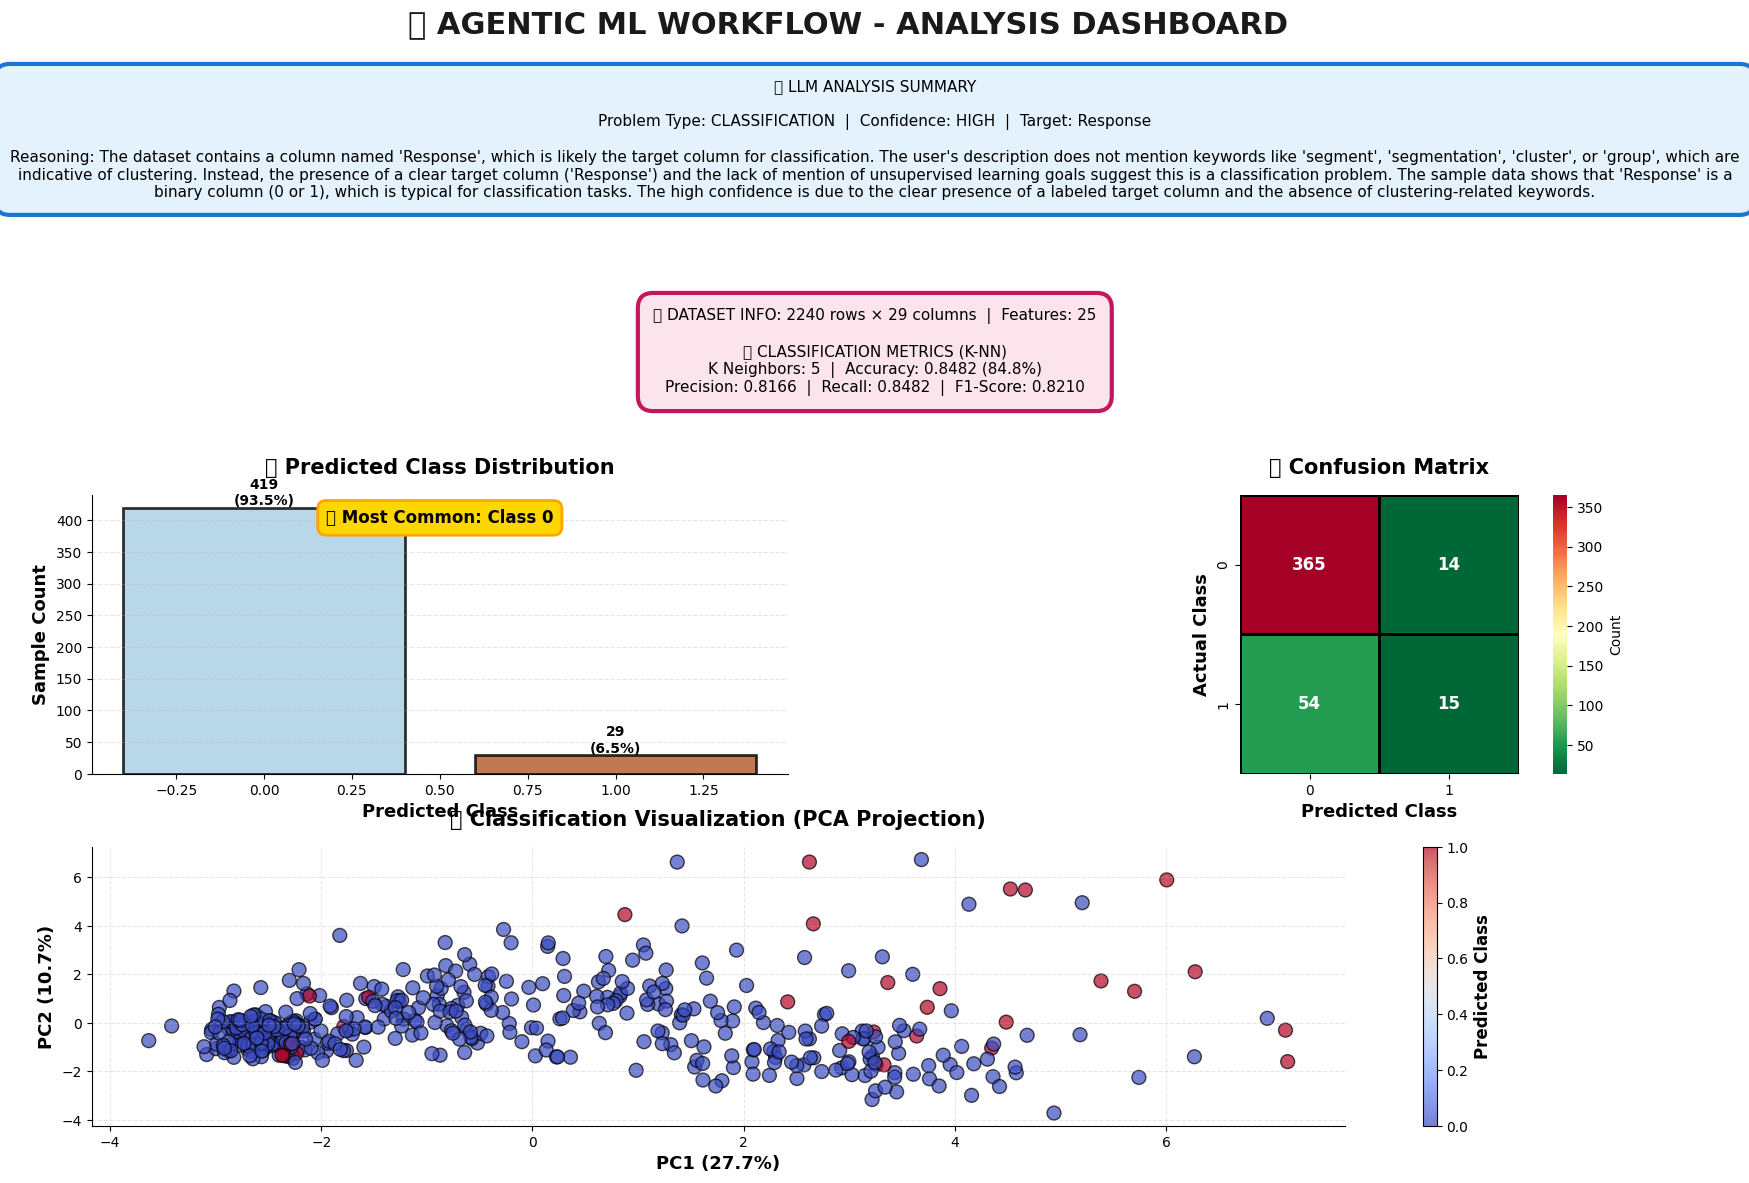

In [3]:
"""
Agentic ML Workflow with LangGraph, Mistral 7B
ENHANCED ACCURACY + CLEAN LAYOUT - Google Colab Ready

Installation Instructions for Google Colab:
!pip install langgraph langchain langchain-community langchain-mistralai
!pip install scikit-learn pandas numpy matplotlib seaborn
!pip install python-dotenv
"""

import os
import json
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, silhouette_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_mistralai import ChatMistralAI

# Set style for beautiful plots
plt.style.use('default')
sns.set_palette("husl")


# =========================
# HELPER FUNCTIONS
# =========================

def safe_json_parse(text: str):
    """Parse JSON from LLM response, handling markdown fences"""
    try:
        # Remove markdown fences if present
        if "```json" in text:
            text = text.split("```json")[1].split("```")[0].strip()
        elif "```" in text:
            text = text.split("```")[1].split("```")[0].strip()

        # Extract JSON object
        start = text.find("{")
        end = text.rfind("}") + 1

        if start == -1 or end == 0:
            raise ValueError("No JSON object found")

        return json.loads(text[start:end])

    except Exception as e:
        raise ValueError(f"LLM JSON parsing failed. Raw output:\n{text}") from e


def detect_target_column(df: pd.DataFrame, description: str):
    """
    Smart detection of target column based on data analysis
    Returns: (has_target, target_column_name, confidence)
    """
    # Keywords that suggest classification
    classification_keywords = ['predict', 'classify', 'classification', 'label', 'category',
                              'target', 'class', 'spam', 'fraud', 'diagnosis', 'species',
                              'type', 'outcome', 'result']

    # Keywords that suggest clustering/segmentation
    clustering_keywords = ['segment', 'segmentation', 'cluster', 'clustering', 'group',
                          'grouping', 'similar', 'pattern', 'customer segmentation',
                          'market segmentation', 'unsupervised']

    description_lower = description.lower()

    # Strong clustering indicators
    if any(keyword in description_lower for keyword in clustering_keywords):
        return False, None, "high"

    # Check for obvious target columns by name
    target_column_names = ['target', 'label', 'class', 'category', 'output', 'y',
                          'species', 'type', 'diagnosis', 'outcome', 'survived',
                          'churn', 'fraud', 'spam']

    for col in df.columns:
        col_lower = col.lower()
        if any(target_name in col_lower for target_name in target_column_names):
            # Check if it's categorical or has limited unique values
            if df[col].dtype == 'object' or df[col].nunique() < len(df) * 0.5:
                return True, col, "high"

    # Check last column if it's categorical
    last_col = df.columns[-1]
    if df[last_col].dtype == 'object' or df[last_col].nunique() < 20:
        # If description mentions classification
        if any(keyword in description_lower for keyword in classification_keywords):
            return True, last_col, "medium"

    # If no clear target found, likely clustering
    return False, None, "medium"


# =========================
# STATE DEFINITION
# =========================

class MLState(TypedDict):
    description: str
    dataset_path: str
    dataset: pd.DataFrame
    original_dataset: pd.DataFrame
    problem_type: str
    llm_reasoning: str
    target_column: str
    confidence: str
    preprocessed_data: np.ndarray
    target: np.ndarray
    optimal_k: int
    k_scores: list
    results: dict
    error: str


# =========================
# AGENTIC WORKFLOW
# =========================

class MLAgenticWorkflow:
    def __init__(self, mistral_api_key: str):
        self.llm = ChatMistralAI(
            model="mistral-small-latest",
            api_key=mistral_api_key,
            temperature=0
        )
        self.workflow = self._build_workflow()

    def _build_workflow(self):
        """Build LangGraph workflow"""
        workflow = StateGraph(MLState)

        workflow.add_node("load_data", self.load_data_node)
        workflow.add_node("analyze_problem", self.analyze_problem_node)
        workflow.add_node("preprocess_data", self.preprocess_data_node)
        workflow.add_node("optimize_hyperparameters", self.optimize_hyperparameters_node)
        workflow.add_node("execute_algorithm", self.execute_algorithm_node)

        workflow.set_entry_point("load_data")
        workflow.add_edge("load_data", "analyze_problem")
        workflow.add_edge("analyze_problem", "preprocess_data")
        workflow.add_edge("preprocess_data", "optimize_hyperparameters")
        workflow.add_edge("optimize_hyperparameters", "execute_algorithm")
        workflow.add_edge("execute_algorithm", END)

        return workflow.compile()

    def load_data_node(self, state: MLState) -> MLState:
        """Node 1: Load CSV dataset"""
        try:
            print("📂 Loading dataset...")
            df = pd.read_csv(state["dataset_path"])
            state["dataset"] = df.copy()
            state["original_dataset"] = df.copy()
            state["error"] = ""
            print(f"✅ Loaded {len(df)} rows, {len(df.columns)} columns")
        except Exception as e:
            state["error"] = f"Data loading failed: {e}"
            print(f"❌ {state['error']}")
        return state

    def analyze_problem_node(self, state: MLState) -> MLState:
        """Node 2: Use ENHANCED multi-step analysis to determine problem type"""
        if state.get("error"):
            return state

        try:
            print("🤖 Analyzing problem with enhanced LLM logic...")
            df = state["dataset"]
            description = state["description"]

            # Step 1: Smart target detection
            has_target, target_col, confidence = detect_target_column(df, description)

            print(f"🔍 Pre-analysis: Target detected={has_target}, Confidence={confidence}")

            # Step 2: Build enhanced prompt for LLM
            # Count categorical vs numeric columns
            categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
            numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

            # Calculate unique value ratios
            unique_ratios = {col: df[col].nunique() / len(df) for col in df.columns}

            prompt = f"""
You are an expert ML engineer. Your task is to determine if this is a CLASSIFICATION or CLUSTERING problem.

CRITICAL RULES:
1. CLUSTERING (Unsupervised Learning):
   - Keywords: "segment", "segmentation", "group", "cluster", "similar", "pattern"
   - Examples: "customer segmentation", "market segmentation", "find groups"
   - NO labeled target column
   - Goal: Find natural groupings in unlabeled data

2. CLASSIFICATION (Supervised Learning):
   - Keywords: "predict", "classify", "label", "categorize"
   - Examples: "predict species", "classify spam", "diagnose disease"
   - HAS a labeled target column
   - Goal: Predict a category based on features

USER DESCRIPTION:
"{description}"

DATASET ANALYSIS:
- Total rows: {len(df)}
- Total columns: {len(df.columns)}
- Column names: {df.columns.tolist()}
- Categorical columns: {categorical_cols}
- Numeric columns: {numeric_cols}
- Potential target column: {target_col if has_target else "NONE DETECTED"}
- Pre-detection confidence: {confidence}

SAMPLE DATA (first 3 rows):
{df.head(3).to_string()}

ANALYSIS CHECKLIST:
1. Does description mention "segment/segmentation/cluster/group"? → CLUSTERING
2. Does description mention "predict/classify/label"? → CLASSIFICATION
3. Is there a clear target column with labels? → CLASSIFICATION
4. Is the goal to find patterns in unlabeled data? → CLUSTERING

Respond ONLY in this JSON format:
{{
  "problem_type": "classification" or "clustering",
  "target_column": "exact_column_name" or null,
  "confidence": "high" or "medium" or "low",
  "reasoning": "Detailed step-by-step explanation of your decision based on the checklist above. Explain which keywords you found, whether a target exists, and why you chose this problem type."
}}
"""

            response = self.llm.invoke(prompt)
            content = response.content.strip()

            result = safe_json_parse(content)

            # Step 3: Validate LLM response with pre-detection
            llm_problem_type = result["problem_type"].lower()
            llm_target = result.get("target_column")
            llm_confidence = result.get("confidence", "medium")

            # Cross-validation logic
            if has_target and llm_problem_type == "clustering":
                print("⚠️ WARNING: LLM suggested clustering but target column detected!")
                print(f"   Overriding to CLASSIFICATION based on target column: {target_col}")
                final_problem_type = "classification"
                final_target = target_col
            elif not has_target and llm_problem_type == "classification":
                print("⚠️ WARNING: LLM suggested classification but no clear target found!")
                # Check if LLM identified a target
                if llm_target and llm_target in df.columns:
                    print(f"   Using LLM-identified target column: {llm_target}")
                    final_problem_type = "classification"
                    final_target = llm_target
                else:
                    print("   Overriding to CLUSTERING (no target column)")
                    final_problem_type = "clustering"
                    final_target = None
            else:
                # Agreement between pre-detection and LLM
                final_problem_type = llm_problem_type
                final_target = llm_target if llm_problem_type == "classification" else None

            state["problem_type"] = final_problem_type
            state["llm_reasoning"] = result.get("reasoning", "No reasoning provided")
            state["confidence"] = llm_confidence
            state["target_column"] = final_target if final_target else "N/A"

            print(f"✅ FINAL DECISION: {final_problem_type.upper()}")
            print(f"📊 Confidence: {llm_confidence}")
            print(f"💡 Reasoning: {state['llm_reasoning'][:150]}...")

            # Extract target for classification
            if final_problem_type == "classification" and final_target and final_target in df.columns:
                state["target"] = df[final_target].values
                state["dataset"] = df.drop(columns=[final_target])
                print(f"🎯 Target column: {final_target}")

        except Exception as e:
            state["error"] = f"Problem analysis failed: {e}"
            print(f"❌ {state['error']}")

        return state

    def preprocess_data_node(self, state: MLState) -> MLState:
        """Node 3: Handle missing values and scaling"""
        if state.get("error"):
            return state

        try:
            print("🔧 Preprocessing data...")
            df = state["dataset"].select_dtypes(include=[np.number])

            # Handle missing values
            df = df.fillna(df.mean())

            # Scale features
            scaler = StandardScaler()
            state["preprocessed_data"] = scaler.fit_transform(df)

            # Encode target for classification
            if state["problem_type"] == "classification" and state.get("target") is not None:
                le = LabelEncoder()
                state["target"] = le.fit_transform(state["target"])

            print(f"✅ Preprocessed shape: {state['preprocessed_data'].shape}")

        except Exception as e:
            state["error"] = f"Preprocessing failed: {e}"
            print(f"❌ {state['error']}")

        return state

    def optimize_hyperparameters_node(self, state: MLState) -> MLState:
        """Node 4: Optimize k using elbow method for clustering"""
        if state.get("error"):
            return state

        try:
            print("⚙️ Optimizing hyperparameters...")

            if state["problem_type"] == "clustering":
                X = state["preprocessed_data"]
                scores = []
                inertias = []
                k_range = range(2, min(11, len(X)))

                for k in k_range:
                    km = KMeans(n_clusters=k, n_init=10, random_state=42)
                    labels = km.fit_predict(X)
                    scores.append(silhouette_score(X, labels))
                    inertias.append(km.inertia_)

                optimal_idx = np.argmax(scores)
                state["optimal_k"] = k_range[optimal_idx]
                state["k_scores"] = list(zip(k_range, scores, inertias))
                print(f"✅ Optimal K (clusters): {state['optimal_k']}")
            else:
                state["optimal_k"] = 5  # Better default for KNN
                state["k_scores"] = []
                print(f"✅ Using K (neighbors): {state['optimal_k']}")

        except Exception as e:
            state["error"] = f"Hyperparameter optimization failed: {e}"
            print(f"❌ {state['error']}")

        return state

    def execute_algorithm_node(self, state: MLState) -> MLState:
        """Node 5: Execute KMeans or KNN"""
        if state.get("error"):
            return state

        try:
            print("🚀 Executing algorithm...")
            X = state["preprocessed_data"]
            k = state["optimal_k"]

            if state["problem_type"] == "clustering":
                # KMeans clustering
                km = KMeans(n_clusters=k, n_init=10, random_state=42)
                labels = km.fit_predict(X)

                state["results"] = {
                    "optimal_k": k,
                    "silhouette_score": silhouette_score(X, labels),
                    "inertia": km.inertia_,
                    "labels": labels,
                    "centers": km.cluster_centers_,
                    "X": X
                }
                print(f"✅ KMeans completed - Silhouette Score: {state['results']['silhouette_score']:.4f}")

            else:
                # KNN classification
                Xtr, Xte, ytr, yte = train_test_split(
                    X, state["target"], test_size=0.2, random_state=42
                )
                knn = KNeighborsClassifier(n_neighbors=k)
                knn.fit(Xtr, ytr)
                preds = knn.predict(Xte)

                state["results"] = {
                    "k": k,
                    "accuracy": accuracy_score(yte, preds),
                    "precision": precision_score(yte, preds, average='weighted', zero_division=0),
                    "recall": recall_score(yte, preds, average='weighted', zero_division=0),
                    "f1_score": f1_score(yte, preds, average='weighted', zero_division=0),
                    "confusion_matrix": confusion_matrix(yte, preds),
                    "predictions": preds,
                    "actual": yte,
                    "X_test": Xte,
                    "X_train": Xtr,
                    "y_train": ytr
                }
                print(f"✅ KNN completed - Accuracy: {state['results']['accuracy']:.4f}")

        except Exception as e:
            state["error"] = f"Algorithm execution failed: {e}"
            print(f"❌ {state['error']}")

        return state

    def run(self, description: str, dataset_path: str) -> MLState:
        """Run the complete workflow"""
        return self.workflow.invoke({
            "description": description,
            "dataset_path": dataset_path,
            "dataset": None,
            "original_dataset": None,
            "problem_type": "",
            "llm_reasoning": "",
            "target_column": "",
            "confidence": "",
            "preprocessed_data": None,
            "target": None,
            "optimal_k": 0,
            "k_scores": [],
            "results": {},
            "error": ""
        })


# =========================
# CLEAN ORGANIZED DASHBOARD
# =========================

def create_clean_dashboard(state: MLState):
    """Create a clean, well-organized visual dashboard"""

    # Create figure with clean grid layout
    fig = plt.figure(figsize=(18, 12))
    fig.patch.set_facecolor('white')

    # Define clean grid: 4 rows, 2 columns
    gs = fig.add_gridspec(4, 2, height_ratios=[1, 1, 2, 2],
                         hspace=0.35, wspace=0.25,
                         left=0.08, right=0.95, top=0.93, bottom=0.05)

    # ==================
    # TITLE
    # ==================
    fig.suptitle('🤖 AGENTIC ML WORKFLOW - ANALYSIS DASHBOARD',
                 fontsize=22, fontweight='bold', color='#1a1a1a', y=0.98)

    # ==================
    # ROW 1: LLM ANALYSIS (FULL WIDTH)
    # ==================
    ax_llm = fig.add_subplot(gs[0, :])
    ax_llm.axis('off')

    llm_box_color = '#E3F2FD' if state['problem_type'] == 'classification' else '#E8F5E9'
    border_color = '#1976D2' if state['problem_type'] == 'classification' else '#388E3C'

    llm_text = f"""🧠 LLM ANALYSIS SUMMARY

Problem Type: {state['problem_type'].upper()}  |  Confidence: {state.get('confidence', 'N/A').upper()}  |  Target: {state.get('target_column', 'N/A')}

Reasoning: {state['llm_reasoning']}"""

    ax_llm.text(0.5, 0.5, llm_text, fontsize=11, family='sans-serif',
                verticalalignment='center', horizontalalignment='center',
                bbox=dict(boxstyle='round,pad=1', facecolor=llm_box_color,
                         edgecolor=border_color, linewidth=3),
                wrap=True)

    # ==================
    # ROW 2: DATASET INFO + METRICS (FULL WIDTH)
    # ==================
    ax_info = fig.add_subplot(gs[1, :])
    ax_info.axis('off')

    df = state['original_dataset']
    results = state['results']

    if state['problem_type'] == 'clustering':
        metrics_text = f"""📊 DATASET INFO: {df.shape[0]} rows × {df.shape[1]} columns  |  Features: {state['preprocessed_data'].shape[1]}

📈 CLUSTERING METRICS (K-MEANS)
Optimal Clusters (K): {results['optimal_k']}  |  Silhouette Score: {results['silhouette_score']:.4f}  |  Inertia: {results['inertia']:.2f}
Quality: {'Excellent' if results['silhouette_score'] > 0.7 else 'Good' if results['silhouette_score'] > 0.5 else 'Fair'}"""

        box_color = '#FFF3E0'
        border_color = '#F57C00'
    else:
        metrics_text = f"""📊 DATASET INFO: {df.shape[0]} rows × {df.shape[1]} columns  |  Features: {state['preprocessed_data'].shape[1]}

🎯 CLASSIFICATION METRICS (K-NN)
K Neighbors: {results['k']}  |  Accuracy: {results['accuracy']:.4f} ({results['accuracy']*100:.1f}%)
Precision: {results['precision']:.4f}  |  Recall: {results['recall']:.4f}  |  F1-Score: {results['f1_score']:.4f}"""

        box_color = '#FCE4EC'
        border_color = '#C2185B'

    ax_info.text(0.5, 0.5, metrics_text, fontsize=11, family='sans-serif',
                verticalalignment='center', horizontalalignment='center',
                bbox=dict(boxstyle='round,pad=1', facecolor=box_color,
                         edgecolor=border_color, linewidth=3))

    # ==================
    # ROW 3 & 4: VISUALIZATIONS
    # ==================

    if state['problem_type'] == 'clustering':
        # ===== CLUSTERING VISUALIZATIONS =====

        # LEFT: Cluster Distribution
        ax1 = fig.add_subplot(gs[2, 0])
        unique, counts = np.unique(results['labels'], return_counts=True)
        colors = plt.cm.Set2(np.linspace(0, 1, len(unique)))
        bars = ax1.bar(unique, counts, color=colors, edgecolor='black', linewidth=2, alpha=0.8)
        ax1.set_xlabel('Cluster ID', fontsize=13, fontweight='bold')
        ax1.set_ylabel('Sample Count', fontsize=13, fontweight='bold')
        ax1.set_title('📊 Cluster Distribution', fontsize=15, fontweight='bold', pad=15)
        ax1.grid(axis='y', alpha=0.3, linestyle='--')
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)

        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}\n({height/len(results["labels"])*100:.1f}%)',
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

        # RIGHT: Elbow Method
        ax2 = fig.add_subplot(gs[2, 1])
        if state['k_scores']:
            k_vals, silhouette_vals, inertia_vals = zip(*state['k_scores'])
            ax2.plot(k_vals, silhouette_vals, marker='o', linewidth=3,
                    markersize=10, color='#E74C3C', markeredgecolor='black',
                    markeredgewidth=2, label='Silhouette Score')
            ax2.axvline(results['optimal_k'], color='#27AE60', linestyle='--',
                       linewidth=3, label=f"Optimal K = {results['optimal_k']}")
            ax2.fill_between(k_vals, silhouette_vals, alpha=0.2, color='#E74C3C')
            ax2.set_xlabel('Number of Clusters (K)', fontsize=13, fontweight='bold')
            ax2.set_ylabel('Silhouette Score', fontsize=13, fontweight='bold')
            ax2.set_title('📈 Elbow Method Analysis', fontsize=15, fontweight='bold', pad=15)
            ax2.legend(fontsize=11, loc='best', frameon=True, shadow=True)
            ax2.grid(True, alpha=0.3, linestyle='--')
            ax2.spines['top'].set_visible(False)
            ax2.spines['right'].set_visible(False)

        # BOTTOM: Cluster Visualization (FULL WIDTH)
        ax3 = fig.add_subplot(gs[3, :])
        X = results['X']
        labels = results['labels']

        if X.shape[1] > 2:
            pca = PCA(n_components=2)
            X_2d = pca.fit_transform(X)
            xlabel = f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)'
            ylabel = f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)'
        else:
            X_2d = X[:, :2]
            xlabel, ylabel = 'Feature 1', 'Feature 2'

        scatter = ax3.scatter(X_2d[:, 0], X_2d[:, 1], c=labels,
                            cmap='viridis', s=100, alpha=0.7,
                            edgecolors='black', linewidth=1)
        ax3.set_xlabel(xlabel, fontsize=13, fontweight='bold')
        ax3.set_ylabel(ylabel, fontsize=13, fontweight='bold')
        ax3.set_title('🎨 Cluster Visualization (PCA Projection)', fontsize=15, fontweight='bold', pad=15)
        cbar = plt.colorbar(scatter, ax=ax3)
        cbar.set_label('Cluster ID', fontsize=12, fontweight='bold')
        ax3.grid(True, alpha=0.3, linestyle='--')
        ax3.spines['top'].set_visible(False)
        ax3.spines['right'].set_visible(False)

    else:
        # ===== CLASSIFICATION VISUALIZATIONS =====

        # LEFT: Class Distribution
        ax1 = fig.add_subplot(gs[2, 0])
        unique, counts = np.unique(results['predictions'], return_counts=True)
        colors = plt.cm.Paired(np.linspace(0, 1, len(unique)))
        bars = ax1.bar(unique, counts, color=colors, edgecolor='black', linewidth=2, alpha=0.8)
        ax1.set_xlabel('Predicted Class', fontsize=13, fontweight='bold')
        ax1.set_ylabel('Sample Count', fontsize=13, fontweight='bold')
        ax1.set_title('📊 Predicted Class Distribution', fontsize=15, fontweight='bold', pad=15)
        ax1.grid(axis='y', alpha=0.3, linestyle='--')
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)

        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}\n({height/len(results["predictions"])*100:.1f}%)',
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

        most_common_idx = np.argmax(counts)
        ax1.text(0.5, 0.95, f'🏆 Most Common: Class {unique[most_common_idx]}',
                transform=ax1.transAxes, ha='center', va='top',
                fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='gold',
                         edgecolor='orange', linewidth=2))

        # RIGHT: Confusion Matrix
        ax2 = fig.add_subplot(gs[2, 1])
        cm = results['confusion_matrix']
        sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', cbar_kws={'label': 'Count'},
                   ax=ax2, linewidths=2, linecolor='black', square=True,
                   annot_kws={'fontsize': 12, 'fontweight': 'bold'})
        ax2.set_xlabel('Predicted Class', fontsize=13, fontweight='bold')
        ax2.set_ylabel('Actual Class', fontsize=13, fontweight='bold')
        ax2.set_title('🔥 Confusion Matrix', fontsize=15, fontweight='bold', pad=15)

        # BOTTOM: Classification Visualization (FULL WIDTH)
        ax3 = fig.add_subplot(gs[3, :])
        X = results['X_test']
        preds = results['predictions']

        if X.shape[1] > 2:
            pca = PCA(n_components=2)
            X_2d = pca.fit_transform(X)
            xlabel = f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)'
            ylabel = f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)'
        else:
            X_2d = X[:, :2]
            xlabel, ylabel = 'Feature 1', 'Feature 2'

        scatter = ax3.scatter(X_2d[:, 0], X_2d[:, 1], c=preds,
                            cmap='coolwarm', s=100, alpha=0.7,
                            edgecolors='black', linewidth=1)
        ax3.set_xlabel(xlabel, fontsize=13, fontweight='bold')
        ax3.set_ylabel(ylabel, fontsize=13, fontweight='bold')
        ax3.set_title('🎨 Classification Visualization (PCA Projection)', fontsize=15, fontweight='bold', pad=15)
        cbar = plt.colorbar(scatter, ax=ax3)
        cbar.set_label('Predicted Class', fontsize=12, fontweight='bold')
        ax3.grid(True, alpha=0.3, linestyle='--')
        ax3.spines['top'].set_visible(False)
        ax3.spines['right'].set_visible(False)

    plt.show()


def print_summary_table(state: MLState):
    """Print clean summary table"""

    print("\n" + "="*90)
    print("📋 WORKFLOW SUMMARY TABLE")
    print("="*90)

    # Analysis Summary
    print("\n🧠 LLM ANALYSIS")
    print("-"*90)
    summary_df = pd.DataFrame({
        'Metric': ['Problem Type', 'Confidence', 'Target Column', 'Dataset Rows', 'Dataset Columns'],
        'Value': [
            state['problem_type'].upper(),
            state.get('confidence', 'N/A').upper(),
            state.get('target_column', 'N/A'),
            state['original_dataset'].shape[0],
            state['original_dataset'].shape[1]
        ]
    })
    print(summary_df.to_string(index=False))

    results = state['results']

    if state['problem_type'] == 'clustering':
        print("\n📊 CLUSTERING RESULTS")
        print("-"*90)

        cluster_df = pd.DataFrame({
            'Cluster ID': np.unique(results['labels']),
            'Sample Count': [np.sum(results['labels'] == i) for i in np.unique(results['labels'])],
            'Percentage': [f"{np.sum(results['labels'] == i)/len(results['labels'])*100:.1f}%"
                          for i in np.unique(results['labels'])]
        })
        print(cluster_df.to_string(index=False))

        print(f"\n📈 Quality Metrics:")
        print(f"   • Silhouette Score: {results['silhouette_score']:.4f}")
        print(f"   • Inertia: {results['inertia']:.2f}")
        print(f"   • Optimal K: {results['optimal_k']}")

    else:
        print("\n🎯 CLASSIFICATION RESULTS")
        print("-"*90)

        class_df = pd.DataFrame({
            'Class ID': np.unique(results['predictions']),
            'Predicted Count': [np.sum(results['predictions'] == i) for i in np.unique(results['predictions'])],
            'Percentage': [f"{np.sum(results['predictions'] == i)/len(results['predictions'])*100:.1f}%"
                          for i in np.unique(results['predictions'])]
        })
        print(class_df.to_string(index=False))

        print(f"\n📊 Performance Metrics:")
        print(f"   • Accuracy:  {results['accuracy']:.4f} ({results['accuracy']*100:.2f}%)")
        print(f"   • Precision: {results['precision']:.4f}")
        print(f"   • Recall:    {results['recall']:.4f}")
        print(f"   • F1-Score:  {results['f1_score']:.4f}")

    print("\n" + "="*90)


# =========================
# CLI RUNNER
# =========================

def run_ml_pipeline_cli():
    """Run the ML pipeline in CLI mode"""
    print("="*90)
    print("🤖 AGENTIC ML WORKFLOW - ENHANCED ACCURACY + CLEAN LAYOUT")
    print("   Powered by Mistral 7B + LangGraph + Advanced Detection")
    print("="*90)

    # Load environment variables from myenv file
    load_dotenv('myenv')

    # Try to get API key from environment variable
    api_key = os.getenv('MISTRAL_API_KEY')

    if api_key:
        print("\n✅ API Key loaded from myenv file")
    else:
        # Fallback to manual input if not found in .env
        print("\n⚠️ MISTRAL_API_KEY not found in myenv file")
        api_key = input("🔑 Enter Mistral API Key manually: ").strip()
        if not api_key:
            print("❌ API key is required")
            return

    # Get Dataset Path
    dataset_path = input("📂 Enter path to CSV dataset: ").strip()
    if not os.path.exists(dataset_path):
        print(f"❌ Dataset file not found: {dataset_path}")
        return

    # Get Description
    print("\n📝 Describe your ML problem:")
    description = input("> ").strip()
    if not description:
        print("❌ Description is required")
        return

    print("\n" + "="*90)
    print("🚀 STARTING ENHANCED WORKFLOW...")
    print("="*90 + "\n")

    # Run workflow
    try:
        workflow = MLAgenticWorkflow(api_key)
        state = workflow.run(description, dataset_path)

        if state.get("error"):
            print(f"\n❌ WORKFLOW FAILED: {state['error']}")
            return

        # Display results
        print("\n" + "="*90)
        print("🎉 WORKFLOW COMPLETED SUCCESSFULLY!")
        print("="*90)

        # Print summary table
        print_summary_table(state)

        # Show clean dashboard
        print("\n📊 Generating Clean Visual Dashboard...")
        create_clean_dashboard(state)

    except Exception as e:
        print(f"\n❌ FATAL ERROR: {e}")
        import traceback
        traceback.print_exc()


# =========================
# ENTRY POINT
# =========================

if __name__ == "__main__":
    run_ml_pipeline_cli()